# Case Study 5: BERT Question Answering on SQuAD
**Objective:** Fine-tune BERT for extractive QA on the SQuAD dataset.
**Covers:** Tokenization & input format, fine-tuning, F1/EM score, span prediction explanation.

In [1]:
!pip install transformers datasets torch scikit-learn matplotlib --quiet

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import collections, string, re
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast, BertForQuestionAnswering,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load SQuAD Dataset

In [3]:
dataset = load_dataset('squad')
# Use small subset for faster training
train_data = dataset['train'].select(range(3000))
val_data   = dataset['validation'].select(range(500))

print(f'Train: {len(train_data)}, Val: {len(val_data)}')
print('\nSample:')
ex = train_data[0]
print(f'  Context:  {ex["context"][:200]}...')
print(f'  Question: {ex["question"]}')
print(f'  Answer:   {ex["answers"]["text"][0]}')

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Train: 3000, Val: 500

Sample:
  Context:  Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper sta...
  Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
  Answer:   Saint Bernadette Soubirous


## 2. Tokenization & Input Format

In [4]:
MODEL_NAME = 'bert-base-uncased'
tokenizer  = BertTokenizerFast.from_pretrained(MODEL_NAME)
MAX_LEN    = 384
STRIDE     = 128

# BERT QA input format:
# [CLS] question tokens [SEP] context tokens [SEP]
# The model predicts start_position and end_position within context tokens

def preprocess(examples):
    questions = [q.strip() for q in examples['question']]
    inputs = tokenizer(
        questions,
        examples['context'],
        max_length=MAX_LEN,
        truncation='only_second',
        stride=STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding='max_length'
    )

    sample_map     = inputs.pop('overflow_to_sample_mapping')
    offset_mapping = inputs.pop('offset_mapping')
    start_positions, end_positions = [], []

    for i, offsets in enumerate(offset_mapping):
        sample_idx  = sample_map[i]
        answers     = examples['answers'][sample_idx]
        seq_ids     = inputs.sequence_ids(i)
        ctx_start   = seq_ids.index(1)
        ctx_end     = len(seq_ids) - 1 - seq_ids[::-1].index(1)

        if len(answers['answer_start']) == 0:
            start_positions.append(0)
            end_positions.append(0)
            continue

        ans_start = answers['answer_start'][0]
        ans_end   = ans_start + len(answers['text'][0])

        # Find token positions of the answer span
        token_start = ctx_start
        while token_start <= ctx_end and offsets[token_start][0] <= ans_start:
            token_start += 1
        start_positions.append(token_start - 1)

        token_end = ctx_end
        while token_end >= ctx_start and offsets[token_end][1] >= ans_end:
            token_end -= 1
        end_positions.append(token_end + 1)

    inputs['start_positions'] = start_positions
    inputs['end_positions']   = end_positions
    return inputs

train_tokenized = train_data.map(preprocess, batched=True, remove_columns=train_data.column_names)
val_tokenized   = val_data.map(preprocess,   batched=True, remove_columns=val_data.column_names)
print(f'Tokenized train: {len(train_tokenized)}, val: {len(val_tokenized)}')

# Show input format
print('\n=== BERT QA Input Format ===')
tokens = tokenizer.convert_ids_to_tokens(train_tokenized[0]['input_ids'][:30])
print(' '.join(tokens))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenized train: 3074, val: 520

=== BERT QA Input Format ===
[CLS] to whom did the virgin mary allegedly appear in 1858 in lou ##rdes france ? [SEP] architectural ##ly , the school has a catholic character . atop the main


## 3. Fine-Tuning BERT for QA

In [5]:
train_tokenized.set_format('torch')
val_tokenized.set_format('torch')

train_loader = DataLoader(train_tokenized, batch_size=8,  shuffle=True)
val_loader   = DataLoader(val_tokenized,   batch_size=16, shuffle=False)

model     = BertForQuestionAnswering.from_pretrained(MODEL_NAME).to(device)
optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
total_steps = len(train_loader) * 3
scheduler = get_linear_schedule_with_warmup(optimizer,
                num_warmup_steps=int(0.1*total_steps),
                num_training_steps=total_steps)

EPOCHS = 3
losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        start_pos      = batch['start_positions'].to(device)
        end_pos        = batch['end_positions'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                        start_positions=start_pos, end_positions=end_pos)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        if step % 100 == 0:
            print(f'  Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {loss.item():.4f}')
    losses.append(total_loss / len(train_loader))
    print(f'Epoch {epoch+1} avg loss: {losses[-1]:.4f}\n')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

  Epoch 1 | Step 0/385 | Loss: 6.0437
  Epoch 1 | Step 100/385 | Loss: 4.0307
  Epoch 1 | Step 200/385 | Loss: 2.9147
  Epoch 1 | Step 300/385 | Loss: 2.5883
Epoch 1 avg loss: 3.4824

  Epoch 2 | Step 0/385 | Loss: 2.1645
  Epoch 2 | Step 100/385 | Loss: 2.0075
  Epoch 2 | Step 200/385 | Loss: 2.2562
  Epoch 2 | Step 300/385 | Loss: 1.3994
Epoch 2 avg loss: 1.5017

  Epoch 3 | Step 0/385 | Loss: 0.8448
  Epoch 3 | Step 100/385 | Loss: 1.0942
  Epoch 3 | Step 200/385 | Loss: 1.3970
  Epoch 3 | Step 300/385 | Loss: 1.1489
Epoch 3 avg loss: 0.8206



## 4. F1 / Exact Match Evaluation

In [6]:
def normalize_answer(s):
    s = s.lower()
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    s = ''.join(c for c in s if c not in string.punctuation)
    return ' '.join(s.split())

def exact_match(pred, gold):
    return int(normalize_answer(pred) == normalize_answer(gold))

def token_f1(pred, gold):
    pred_tokens  = normalize_answer(pred).split()
    gold_tokens  = normalize_answer(gold).split()
    common       = collections.Counter(pred_tokens) & collections.Counter(gold_tokens)
    num_same     = sum(common.values())
    if num_same == 0: return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

# Predict on validation
model.eval()
em_scores, f1_scores = [], []
predictions = []

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        start_logits = outputs.start_logits.cpu()
        end_logits   = outputs.end_logits.cpu()

        for i in range(len(input_ids)):
            start_idx = start_logits[i].argmax().item()
            end_idx   = max(start_idx, end_logits[i].argmax().item())
            tokens    = batch['input_ids'][i][start_idx:end_idx+1]
            pred_ans  = tokenizer.decode(tokens, skip_special_tokens=True)
            predictions.append(pred_ans)

# Compare against gold answers
gold_answers = [ex['answers']['text'] for ex in val_data]
# val_tokenized may have more rows due to stride; align with original val_data
for i, pred in enumerate(predictions[:len(gold_answers)]):
    golds = gold_answers[i]
    em = max(exact_match(pred, g) for g in golds)
    f1 = max(token_f1(pred, g)    for g in golds)
    em_scores.append(em)
    f1_scores.append(f1)

print(f'Exact Match (EM): {np.mean(em_scores)*100:.2f}%')
print(f'Token F1 Score:   {np.mean(f1_scores)*100:.2f}%')

# Sample predictions
print('\n=== Sample Predictions ===')
for i in range(5):
    print(f'Q: {val_data[i]["question"]}')
    print(f'Gold:  {gold_answers[i][0]}')
    print(f'Pred:  {predictions[i]}')
    print(f'EM: {em_scores[i]} | F1: {f1_scores[i]:.2f}\n')

Exact Match (EM): 29.60%
Token F1 Score:   32.96%

=== Sample Predictions ===
Q: Which NFL team represented the AFC at Super Bowl 50?
Gold:  Denver Broncos
Pred:  denver broncos
EM: 1 | F1: 1.00

Q: Which NFL team represented the NFC at Super Bowl 50?
Gold:  Carolina Panthers
Pred:  denver broncos
EM: 0 | F1: 0.00

Q: Where did Super Bowl 50 take place?
Gold:  Santa Clara, California
Pred:  arabic
EM: 0 | F1: 0.00

Q: Which NFL team won Super Bowl 50?
Gold:  Denver Broncos
Pred:  arabic
EM: 0 | F1: 0.00

Q: What color was used to emphasize the 50th anniversary of the Super Bowl?
Gold:  gold
Pred:  arabic
EM: 0 | F1: 0.00



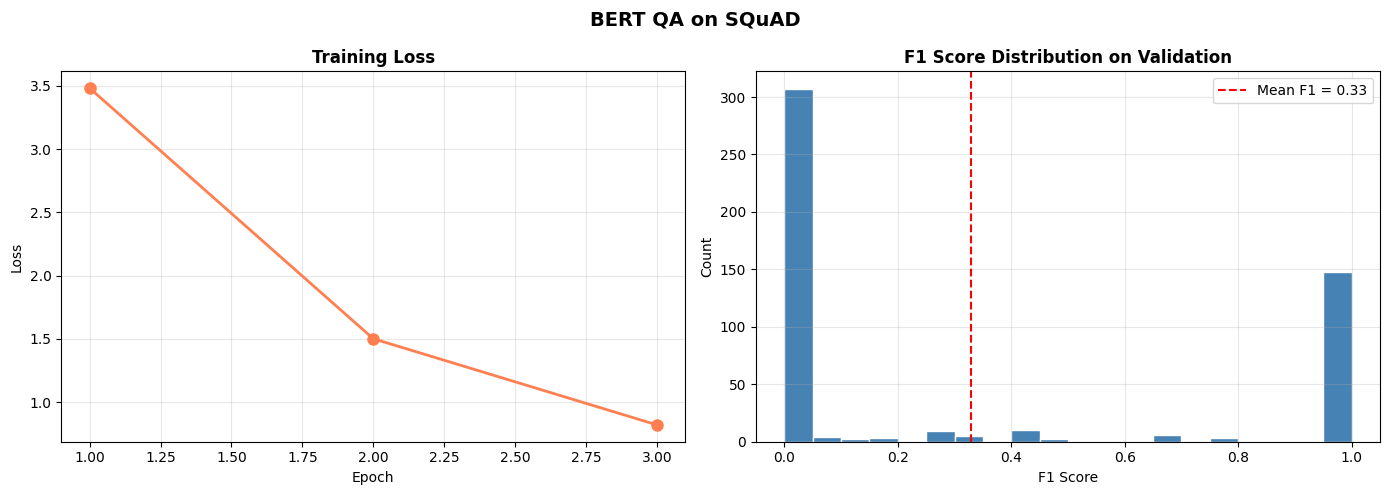

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS+1), losses, 'o-', color='coral', linewidth=2, markersize=8)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(True, alpha=0.3)

axes[1].hist(f1_scores, bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(np.mean(f1_scores), color='red', linestyle='--',
                label=f'Mean F1 = {np.mean(f1_scores):.2f}')
axes[1].set_title('F1 Score Distribution on Validation', fontweight='bold')
axes[1].set_xlabel('F1 Score'); axes[1].set_ylabel('Count')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('BERT QA on SQuAD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lab5_bert_qa_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Explanation of Span Prediction

### How BERT QA works
BERT for QA is an **extractive** model — it selects a span from the context rather than generating a new answer.

**Input format:**
```
[CLS] question tokens [SEP] context tokens [SEP]
```

**Output:** Two logit vectors of length = sequence length:
- `start_logits[i]` = probability that token i is the **start** of the answer
- `end_logits[i]`   = probability that token i is the **end** of the answer

The final answer = `context[argmax(start_logits) : argmax(end_logits)+1]`

### Metrics
| Metric | Definition |
|--------|------------|
| **Exact Match (EM)** | 1 if predicted string exactly matches any gold answer (after normalization), else 0 |
| **Token F1** | Token-level overlap between prediction and gold answer — partial credit for partially correct spans |

**Why both?** EM is strict and penalizes any word difference. F1 is more lenient and gives credit for partial matches. Real SQuAD leaderboards report both.

### Expected performance (SQuAD v1.1)
| Model | EM | F1 |
|-------|----|---------|
| BERT-base fine-tuned (full data) | ~80% | ~88% |
| BERT-base fine-tuned (3k samples) | ~55–65% | ~65–75% |